# ***Опис проєкту:***

ДатаСет містить інформацію щодо продажів продукції компанії, яка працює на світовому ринку і продає товари у звичайних магазинах та інтернет-магазинах. Датасет складається з 3-х таблиць:


---

1. ***`events.csv`*** — продажі за декілька років, дає інформацію про дії користувачів (події). Складається з 1330 записів та 10 змінних:

***Order ID:*** id замовлення;

***Order Date:*** дата замовлення;

***Ship Date:*** дата відвавнтаження;

***Order Priority:*** пріорітет замовлення;

***Country Code:*** код країни;

***Product ID:***	id товару;

***Sales Channel:*** канал продажу;

***Units Sold:*** кількість проданих одиниць товару;

***Unit Price:***	ціна за одиницю товару;

***Unit Cost:*** витрат на одиницю товару.


---


2. ***products.csv*** — категорії товарів та їх коди, деталізує характеристики продуктів. Складається з 12 записів та 2 змінні:

***id:*** id товару;

***item_type:*** вид товару.



---


3. ***countries.csv*** — країни, регіони та їх коди, додає географічний контекст через коди країн. Складається з 249 записів та 5 змінних:

***name:*** назва країни;

***alpha-2:***	двосимвольний код країни;

***alpha-3:***	трьосимвольний код країни;

***region:***	назва регіону;

***sub-region:*** назва субрегіону.


---


***Основна мета завдання:***

*  очищення даних та проведення їх аналізу;

* знаходження цінних інсайтів діяльності компанії.

# ***Етапи проєкту:***

# ***1. Data overview. Розуміння даних та їх змісту***




* Завантаж датасет, розберись зі змістом колонок, зроби їх опис.

* Вияви ключові поля, що поєднують три таблиці.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
file_path_events = '/content/drive/My Drive/events.csv'
df_events = pd.read_csv(file_path_events)
df_events

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,1/10/2017,1/13/2017,M,SWE,4594,Online,4734.0,9.33,6.92
1326,994978797,12/5/2014,1/2/2015,H,ITA,1270,Offline,5192.0,47.45,31.79
1327,996754205,9/20/2010,9/22/2010,L,RUS,7331,Offline,574.0,255.28,159.42
1328,998043382,6/15/2010,7/3/2010,H,MLT,8293,Online,2070.0,437.20,263.33


In [3]:
file_path_products = '/content/drive/My Drive/products.csv'
df_products = pd.read_csv(file_path_products)
df_products

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies
5,4594,Fruits
6,5988,Vegetables
7,7331,Baby Food
8,8875,Meat
9,8293,Cosmetics


In [4]:
file_path_countries = '/content/drive/My Drive/countries.csv'
df_countries = pd.read_csv(file_path_countries)
df_countries

,name,alpha-2,alpha-3,region,sub-region
0,Afghanistan,AF,AFG,Asia,Southern Asia
1,Åland Islands,AX,ALA,Europe,Northern Europe
2,Albania,AL,ALB,Europe,Southern Europe
3,Algeria,DZ,DZA,Africa,Northern Africa
4,American Samoa,AS,ASM,Oceania,Polynesia
...,...,...,...,...,...
244,Wallis and Futuna,WF,WLF,Oceania,Polynesia
245,Western Sahara,EH,ESH,Africa,Northern Africa
246,Yemen,YE,YEM,Asia,Western Asia
247,Zambia,ZM,ZMB,Africa,Sub-Saharan Africa


✅ ***Вияви ключові поля, що поєднують три таблиці:***

1. events.csv 🆚 products.csv


поле ***"Product ID"*** у таблиці ***events.csv*** відповідає полю ***"id"*** у таблиці ***products.csv***


---




2. events.csv 🆚 countries.csv

поле ***"Country Code"*** у таблиці ***countries.csv*** відповідає полю ***"alpha-3"*** у таблиці ***countries.csv***


# ***2. Data cleaning. Робота із пропущеними даними, некоректними даними, аномаліями.***



* Подивись, чи є пропущені значення у кожній таблиці, оціни їх долю, спробуй зрозуміти причини їх виникнення.

* Заповни або видали пропущені значення, обґрунтувавши свою думку.
Подивись, чи всі типи даних розпізнаються коректно. Якщо є розбіжності, потрібно виявити та усунути причини, за потреби, зробити перетворення типів у колонках.

* Досліди дані на наявність дублікатів. Зверни увагу, що дублікати можуть траплятися через зайві пробіли (або інші символи) у комірках, розбіжність у великих/малих літерах, схожість літер у кирилиці/латиниці тощо. За потреби, зроби перетворення для усунення дублікатів.

* Досліди дані на наявність аномалій. Якщо є, спробуй зрозуміти причини.


##***events***

🔷 ***Подивись, чи є пропущені значення у кожній таблиці, оціни їх долю, спробуй зрозуміти причини їх виникнення.***

In [5]:
df_events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,82
Product ID,0
Sales Channel,0
Units Sold,2
Unit Price,0
Unit Cost,0


📌 ***Доля пропущених значення events.csv***

In [6]:
missing_counts_events = df_events.isna().sum()
print("Пропущені значення:", missing_counts_events)

missing_percent_events = df_events.isna().mean() * 100
print("\nДоля пропущених значення:", missing_percent_events)

Пропущені значення: Order ID           0
Order Date         0
Ship Date          0
Order Priority     0
Country Code      82
Product ID         0
Sales Channel      0
Units Sold         2
Unit Price         0
Unit Cost          0
dtype: int64

Доля пропущених значення: Order ID          0.000000
Order Date        0.000000
Ship Date         0.000000
Order Priority    0.000000
Country Code      6.165414
Product ID        0.000000
Sales Channel     0.000000
Units Sold        0.150376
Unit Price        0.000000
Unit Cost         0.000000
dtype: float64


In [7]:
missing_sumup_events = pd.DataFrame({"missing_counts_events": round(missing_counts_events, 2), "missing_percent_events": round(missing_percent_events, 2)})

print(missing_sumup_events)

                missing_counts_events  missing_percent_events
Order ID                            0                    0.00
Order Date                          0                    0.00
Ship Date                           0                    0.00
Order Priority                      0                    0.00
Country Code                       82                    6.17
Product ID                          0                    0.00
Sales Channel                       0                    0.00
Units Sold                          2                    0.15
Unit Price                          0                    0.00
Unit Cost                           0                    0.00


In [8]:
df_events[df_events.isna().any(axis=1)].head(84)

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
2,101025998,7/18/2014,8/11/2014,M,NaN,7940,Online,4693.0,668.27,502.54
13,104548490,1/1/2014,1/5/2014,M,NaN,7331,Online,7076.0,255.28,159.42
26,117929494,1/24/2015,3/2/2015,H,NaN,4594,Offline,6813.0,9.33,6.92
29,118859469,6/2/2011,7/1/2011,L,NaN,8969,Offline,2013.0,152.58,97.44
43,126948583,5/24/2017,7/9/2017,C,NaN,7331,Online,5762.0,255.28,159.42
...,...,...,...,...,...,...,...,...,...,...
1213,919922006,8/27/2011,9/18/2011,L,NaN,4594,Online,4219.0,9.33,6.92
1220,922564303,3/17/2017,4/2/2017,L,NaN,7940,Offline,6134.0,668.27,502.54
1250,941061675,3/8/2017,3/20/2017,M,NaN,5988,Offline,9917.0,154.06,90.93
1296,975080668,7/23/2017,8/20/2017,C,NaN,5988,Offline,6893.0,154.06,90.93


🔷 ***видалення пропущених значень в стовпці*** ***`Units Sold'`***

In [9]:
df_events = df_events.dropna(subset=['Units Sold'])

✅ ***Обгрунтування видалення пропущених значень в стовці `Units Sold`:***

* не викривляє загальну статистику, відсутніх даних ~ 0.15%.

🔷 ***Заповнення відсутніх значень в стовпці*** ***`Country Code`***

In [10]:
df_events = df_events.copy()
df_events["Country Code"] = df_events["Country Code"].fillna("Unknown")

✅ ***Обгрунтування заповнення пропущених значень в стовці `Country Code`:***

* враховуючи те, що частка відсутніх значень ~ 6%, видалення їх не бажано, тому що це може призвести до спотворення загального результату аналізу;

* доцільно, заповнити значенням - `Unknown`. Маніпуляції з даними збережуть записи у вибірці, уникнут викривлення статистики.

In [11]:
df_events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0




---



In [12]:
df_events.head()

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost
0,100640618,10/8/2014,10/18/2014,M,NOR,2103,Online,650.0,205.70,117.11
1,100983083,8/11/2016,8/11/2016,C,SRB,2103,Offline,1993.0,205.70,117.11
2,101025998,7/18/2014,8/11/2014,M,Unknown,7940,Online,4693.0,668.27,502.54
3,102230632,5/13/2017,6/13/2017,L,MNE,2455,Online,1171.0,109.28,35.84
4,103435266,8/11/2012,9/18/2012,H,SRB,1270,Offline,7648.0,47.45,31.79


In [13]:
df_events.isna().sum()

,0
Order ID,0
Order Date,0
Ship Date,0
Order Priority,0
Country Code,0
Product ID,0
Sales Channel,0
Units Sold,0
Unit Price,0
Unit Cost,0




---



🔷 ***Подивись, чи всі типи даних розпізнаються коректно. Якщо є розбіжності, потрібно виявити та усунути причини, за потреби, зробити перетворення типів у колонках***

In [14]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Order ID        1328 non-null   int64  
 1   Order Date      1328 non-null   object 
 2   Ship Date       1328 non-null   object 
 3   Order Priority  1328 non-null   object 
 4   Country Code    1328 non-null   object 
 5   Product ID      1328 non-null   int64  
 6   Sales Channel   1328 non-null   object 
 7   Units Sold      1328 non-null   float64
 8   Unit Price      1328 non-null   float64
 9   Unit Cost       1328 non-null   float64
dtypes: float64(3), int64(2), object(5)
memory usage: 146.4+ KB


✅ тип даних в стовпцях ***`Order Date`,	`Ship Date`*** - `object`, потрібно змінити на тип даних - ***datetime***

✅ тип даних в стовпці ***`Units Sold`*** - `float64`, доцільно змінити на ціле число `int64`

In [15]:
df_events["Order Date"] = pd.to_datetime(df_events["Order Date"], errors="coerce")
df_events["Ship Date"] = pd.to_datetime(df_events["Ship Date"], errors="coerce")
df_events["Units Sold"] = df_events["Units Sold"].astype('int64')

In [16]:
df_events.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1328 entries, 0 to 1329
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        1328 non-null   int64         
 1   Order Date      1328 non-null   datetime64[ns]
 2   Ship Date       1328 non-null   datetime64[ns]
 3   Order Priority  1328 non-null   object        
 4   Country Code    1328 non-null   object        
 5   Product ID      1328 non-null   int64         
 6   Sales Channel   1328 non-null   object        
 7   Units Sold      1328 non-null   int64         
 8   Unit Price      1328 non-null   float64       
 9   Unit Cost       1328 non-null   float64       
dtypes: datetime64[ns](2), float64(2), int64(3), object(3)
memory usage: 146.4+ KB


🔷 ***Досліди дані на наявність дублікатів***

In [17]:
cols_to_clean = ["Order Priority", "Country Code", "Sales Channel"]

for i in cols_to_clean:
  df_events.loc[:, i] = df_events[i].str.strip().str.title()

In [18]:
for i in cols_to_clean:
  print(f"Унікальні значення в '{i}': ")
  print(df_events[i].unique())
  print("\n")

Унікальні значення в 'Order Priority': 
['M' 'C' 'L' 'H']


Унікальні значення в 'Country Code': 
['Nor' 'Srb' 'Unknown' 'Mne' 'Svk' 'Fra' 'Esp' 'Hrv' 'Deu' 'Arm' 'Geo'
 'Gbr' 'Svn' 'Rou' 'Pol' 'Lux' 'Cyp' 'Bel' 'Ltu' 'Rus' 'Mlt' 'Ukr' 'Cze'
 'Prt' 'Blr' 'Est' 'Aut' 'Mkd' 'Smr' 'Nld' 'Che' 'Hun' 'Lva' 'Bgr' 'Ita'
 'Irl' 'And' 'Lie' 'Fin' 'Alb' 'Swe' 'Bih' 'Dnk' 'Mco' 'Isl' 'Grc']


Унікальні значення в 'Sales Channel': 
['Online' 'Offline']




In [19]:
print("✅ Дублікатів:", df_events.duplicated().sum())

✅ Дублікатів: 0


In [20]:
df_events["Order Date"].min(), df_events["Order Date"].max()

(Timestamp('2010-01-01 00:00:00'), Timestamp('2017-07-23 00:00:00'))

 ***🔷 Досліди дані на наявність аномалій. Якщо є, спробуй зрозуміти причини.***

In [21]:
df_events.describe()

,Order ID,Order Date,Ship Date,Product ID,Units Sold,Unit Price,Unit Cost
count,1.328000e+03,1328,1328,1328.000000,1328.000000,1328.000000,1328.000000
mean,5.416231e+08,2013-10-11 22:28:54.939759104,2013-11-05 17:22:02.891566336,5787.775602,4952.201807,264.913245,187.211521
min,1.006406e+08,2010-01-01 00:00:00,2010-01-10 00:00:00,1270.000000,2.000000,9.330000,6.920000
25%,3.213291e+08,2011-12-14 06:00:00,2012-01-02 00:00:00,3127.000000,2356.750000,81.730000,35.840000
50%,5.399925e+08,2013-10-15 12:00:00,2013-11-05 12:00:00,5988.000000,4962.000000,154.060000,97.440000
75%,7.547357e+08,2015-08-29 12:00:00,2015-10-04 18:00:00,8681.000000,7459.500000,437.200000,263.330000
max,9.998797e+08,2017-07-23 00:00:00,2017-08-31 00:00:00,8969.000000,9999.000000,668.270000,524.960000
std,2.573496e+08,NaN,NaN,2820.635702,2905.198996,217.386320,176.187801


In [22]:
df_events[df_events["Ship Date"]< df_events["Order Date"]]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


In [23]:
df_events[df_events["Unit Cost"] > df_events["Unit Price"]]

,Order ID,Order Date,Ship Date,Order Priority,Country Code,Product ID,Sales Channel,Units Sold,Unit Price,Unit Cost


✅ Аномалій в df_events - не виявлено.

## ***products***

 ***🔷 чи є пропущені значення у таблиці products, оціни їх долю, спробуй зрозуміти причини їх виникнення.***



In [24]:
df_products.isna().sum()

,0
id,0
item_type,0


***🔷 Подивись, чи всі типи даних розпізнаються коректно. Якщо є розбіжності, потрібно виявити та усунути причини, за потреби, зробити перетворення типів у колонках***

In [25]:
df_products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   id         12 non-null     int64 
 1   item_type  12 non-null     object
dtypes: int64(1), object(1)
memory usage: 324.0+ bytes


***🔷 Досліди дані на наявність дублікатів***

In [26]:
cols_to_clean1 = ["item_type"]

for i in cols_to_clean1:
  df_products.loc[:, i] = (df_products[i].str.strip().str.title())

for i in cols_to_clean1:
  print(f"Унікальні значення в '{i}': ")
  print(df_products[i].unique())
  print("\n")


Унікальні значення в 'item_type': 
['Cereal' 'Household' 'Clothes' 'Beverages' 'Office Supplies' 'Fruits'
 'Vegetables' 'Baby Food' 'Meat' 'Cosmetics' 'Snacks' 'Personal Care']




In [27]:
print("✅ Дублікатів:", df_products.duplicated().sum())

✅ Дублікатів: 0


***🔷 Досліди дані на наявність аномалій. Якщо є, спробуй зрозуміти причини.***


In [28]:
df_products.head(12)

,id,item_type
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies
5,4594,Fruits
6,5988,Vegetables
7,7331,Baby Food
8,8875,Meat
9,8293,Cosmetics


***✅ Аномалії відсутні.***

## ***countries***

***🔷 чи є пропущені значення у таблиці countries, оціни їх долю, спробуй зрозуміти причини їх виникнення.***

In [29]:
df_countries.isna().sum()

,0
name,0
alpha-2,1
alpha-3,0
region,1
sub-region,1


In [30]:
missing_counts_countries = df_countries.isna().sum()
print("Пропущені значення:", missing_counts_countries)

missing_percent_countries  = df_countries.isna().mean() * 100
print("\nДоля пропущених значення:", round(missing_percent_countries, 1))

Пропущені значення: name          0
alpha-2       1
alpha-3       0
region        1
sub-region    1
dtype: int64

Доля пропущених значення: name          0.0
alpha-2       0.4
alpha-3       0.0
region        0.4
sub-region    0.4
dtype: float64


In [31]:
df_countries[df_countries.isna().any(axis=1)].head()

,name,alpha-2,alpha-3,region,sub-region
8,Antarctica,AQ,ATA,NaN,NaN
153,Namibia,NaN,NAM,Africa,Sub-Saharan Africa


🔷 ***видалення пропущених значень в `df_countries`***

✅ ***Обгрунтування видалення пропущених значень:***

не викривляє загальну статистику, відсутніх даних ~ 0.4%.

In [32]:
df_countries = df_countries.dropna()
df_countries.isna().sum()

,0
name,0
alpha-2,0
alpha-3,0
region,0
sub-region,0


 ***🔷 Подивись, чи всі типи даних розпізнаються коректно. Якщо є розбіжності, потрібно виявити та усунути причини, за потреби, зробити перетворення типів у колонках***


In [33]:
df_countries.info()

<class 'pandas.core.frame.DataFrame'>
Index: 247 entries, 0 to 248
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   name        247 non-null    object
 1   alpha-2     247 non-null    object
 2   alpha-3     247 non-null    object
 3   region      247 non-null    object
 4   sub-region  247 non-null    object
dtypes: object(5)
memory usage: 11.6+ KB


***🔷 Досліди дані на наявність дублікатів***



In [34]:
cols_to_clean3 = ["name", "alpha-2", "alpha-3", "region", "sub-region"]

for i in cols_to_clean3:
  df_countries.loc[:, i] = (df_countries[i].str.strip().str.title())


for i in cols_to_clean3:
  print(f"Унікальні значення в '{i}': ")
  print(df_countries[i].unique())
  print("\n")

Унікальні значення в 'name': 
['Afghanistan' 'Åland Islands' 'Albania' 'Algeria' 'American Samoa'
 'Andorra' 'Angola' 'Anguilla' 'Antigua And Barbuda' 'Argentina' 'Armenia'
 'Aruba' 'Australia' 'Austria' 'Azerbaijan' 'Bahamas' 'Bahrain'
 'Bangladesh' 'Barbados' 'Belarus' 'Belgium' 'Belize' 'Benin' 'Bermuda'
 'Bhutan' 'Bolivia (Plurinational State Of)'
 'Bonaire, Sint Eustatius And Saba' 'Bosnia And Herzegovina' 'Botswana'
 'Bouvet Island' 'Brazil' 'British Indian Ocean Territory'
 'Brunei Darussalam' 'Bulgaria' 'Burkina Faso' 'Burundi' 'Cabo Verde'
 'Cambodia' 'Cameroon' 'Canada' 'Cayman Islands'
 'Central African Republic' 'Chad' 'Chile' 'China' 'Christmas Island'
 'Cocos (Keeling) Islands' 'Colombia' 'Comoros' 'Congo'
 'Congo, Democratic Republic Of The' 'Cook Islands' 'Costa Rica'
 "Côte D'Ivoire" 'Croatia' 'Cuba' 'Curaçao' 'Cyprus' 'Czech Republic'
 'Denmark' 'Djibouti' 'Dominica' 'Dominican Republic' 'Ecuador' 'Egypt'
 'El Salvador' 'Equatorial Guinea' 'Eritrea' 'Estonia' 'Eswatin

***🔷 Досліди дані на наявність аномалій. Якщо є, спробуй зрозуміти причини.***


In [35]:
df_countries.describe()

,name,alpha-2,alpha-3,region,sub-region
count,247,247,247,247,247
unique,247,247,247,5,17
top,Afghanistan,Af,Afg,Africa,Latin America And The Caribbean
freq,1,1,1,59,52


***✅ Аномалії відсутні.***

#***3.Data analysis and visualization. Аналіз та візуалізація даних, знаходження цінних інсайтів.***


* Проведи з’єднання трьох таблиць в один датафрейм. Видали непотрібні для аналізу колонки. За потреби, зроби перейменування колонок.

* Розпочни з ключових метрик діяльності компанії: загальна кількість замовлень, загальний прибуток, загальна кількість охоплених країн тощо (придумай інші метрики).

* Проаналізуй продажі (доходи, витрати, прибутки, популярність товарів) та зроби відповідні візуалізації в розрізі:

   * категорій товарів;
   * географії (країн, регіонів);
   * каналів продажу (онлайн або офлайн).

* Проаналізуй інтервал часу між замовленням та його відвантаженням та зроби відповідні візуалізації в розрізі:

  * категорій товарів;
  * країн;
  * регіонів.

* Проаналізуй, чи залежить прибуток від часу, необхідного на відвантаження товару. Зроби потрібні для цього агрегування та візуалізації.

* Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі категорій товарів, країн, регіонів, визнач основні тенденції.

* Проведи аналіз продажів товарів за днями тижня. Чи можна деякі товари вважати сезонними?

💡 Для знаходження дня тижня за датою скористайся методом day_name().



##🔷***Проведи з’єднання трьох таблиць в один датафрейм. Видали непотрібні для аналізу колонки. За потреби, зроби перейменування колонок.***

In [36]:
df_events.columns = df_events.columns.str.lower().str.replace(" ", "_")
df_products.columns = df_products.columns.str.lower().str.replace(" ", "_")
df_countries.columns = df_countries.columns.str.lower().str.replace("-", "_")

In [37]:
df_events

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost
0,100640618,2014-10-08,2014-10-18,M,Nor,2103,Online,650,205.70,117.11
1,100983083,2016-08-11,2016-08-11,C,Srb,2103,Offline,1993,205.70,117.11
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54
3,102230632,2017-05-13,2017-06-13,L,Mne,2455,Online,1171,109.28,35.84
4,103435266,2012-08-11,2012-09-18,H,Srb,1270,Offline,7648,47.45,31.79
...,...,...,...,...,...,...,...,...,...,...
1325,994504153,2017-01-10,2017-01-13,M,Swe,4594,Online,4734,9.33,6.92
1326,994978797,2014-12-05,2015-01-02,H,Ita,1270,Offline,5192,47.45,31.79
1327,996754205,2010-09-20,2010-09-22,L,Rus,7331,Offline,574,255.28,159.42
1328,998043382,2010-06-15,2010-07-03,H,Mlt,8293,Online,2070,437.20,263.33


In [38]:
df_countries = df_countries.rename(columns={"alpha_3": "country_code", "name": "country_name"})
df_products = df_products.rename(columns={"id": "product_id", "item_type": "product_category"})

In [39]:
df_products.head()

,product_id,product_category
0,2103,Cereal
1,7940,Household
2,2455,Clothes
3,1270,Beverages
4,8681,Office Supplies


In [40]:
df = pd.merge(df_events, df_products, on='product_id', how='inner')
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,product_category
0,100640618,2014-10-08,2014-10-18,M,Nor,2103,Online,650,205.70,117.11,Cereal
1,100983083,2016-08-11,2016-08-11,C,Srb,2103,Offline,1993,205.70,117.11,Cereal
2,101025998,2014-07-18,2014-08-11,M,Unknown,7940,Online,4693,668.27,502.54,Household
3,102230632,2017-05-13,2017-06-13,L,Mne,2455,Online,1171,109.28,35.84,Clothes
4,103435266,2012-08-11,2012-09-18,H,Srb,1270,Offline,7648,47.45,31.79,Beverages


In [41]:
df = pd.merge(df_events, df_countries, on='country_code', how='inner')
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,alpha_2,region,sub_region
0,100640618,2014-10-08,2014-10-18,M,Nor,2103,Online,650,205.70,117.11,Norway,No,Europe,Northern Europe
1,100983083,2016-08-11,2016-08-11,C,Srb,2103,Offline,1993,205.70,117.11,Serbia,Rs,Europe,Southern Europe
2,102230632,2017-05-13,2017-06-13,L,Mne,2455,Online,1171,109.28,35.84,Montenegro,Me,Europe,Southern Europe
3,103435266,2012-08-11,2012-09-18,H,Srb,1270,Offline,7648,47.45,31.79,Serbia,Rs,Europe,Southern Europe
4,103450715,2015-03-15,2015-04-18,H,Svk,8681,Online,2220,651.21,524.96,Slovakia,Sk,Europe,Eastern Europe


In [42]:
df = pd.merge(df, df_products, on='product_id', how='inner')
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,alpha_2,region,sub_region,product_category
0,100640618,2014-10-08,2014-10-18,M,Nor,2103,Online,650,205.70,117.11,Norway,No,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,Srb,2103,Offline,1993,205.70,117.11,Serbia,Rs,Europe,Southern Europe,Cereal
2,102230632,2017-05-13,2017-06-13,L,Mne,2455,Online,1171,109.28,35.84,Montenegro,Me,Europe,Southern Europe,Clothes
3,103435266,2012-08-11,2012-09-18,H,Srb,1270,Offline,7648,47.45,31.79,Serbia,Rs,Europe,Southern Europe,Beverages
4,103450715,2015-03-15,2015-04-18,H,Svk,8681,Online,2220,651.21,524.96,Slovakia,Sk,Europe,Eastern Europe,Office Supplies


In [43]:
df = df.drop('alpha_2', axis=1)
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,region,sub_region,product_category
0,100640618,2014-10-08,2014-10-18,M,Nor,2103,Online,650,205.70,117.11,Norway,Europe,Northern Europe,Cereal
1,100983083,2016-08-11,2016-08-11,C,Srb,2103,Offline,1993,205.70,117.11,Serbia,Europe,Southern Europe,Cereal
2,102230632,2017-05-13,2017-06-13,L,Mne,2455,Online,1171,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes
3,103435266,2012-08-11,2012-09-18,H,Srb,1270,Offline,7648,47.45,31.79,Serbia,Europe,Southern Europe,Beverages
4,103450715,2015-03-15,2015-04-18,H,Svk,8681,Online,2220,651.21,524.96,Slovakia,Europe,Eastern Europe,Office Supplies


In [44]:
len(df['country_name'].unique())

45

##🔷***Розпочни з ключових метрик діяльності компанії: загальна кількість замовлень, загальний прибуток, загальна кількість охоплених країн тощо (придумай інші метрики).***

In [45]:
df["total_revenue"] = df['units_sold'] * df['unit_price']
df["total_cost"] = df['units_sold'] * df['unit_cost']
df["shipping_lead_time"] = (df['ship_date'] - df["order_date"]).dt.days
df["year"] = df["order_date"].dt.year
df["month"] = df["order_date"].dt.month
df["weekday"] = df["order_date"].dt.day_name()

In [46]:
df.head()

,order_id,order_date,ship_date,order_priority,country_code,product_id,sales_channel,units_sold,unit_price,unit_cost,country_name,region,sub_region,product_category,total_revenue,total_cost,shipping_lead_time,year,month,weekday
0,100640618,2014-10-08,2014-10-18,M,Nor,2103,Online,650,205.70,117.11,Norway,Europe,Northern Europe,Cereal,133705.00,76121.50,10,2014,10,Wednesday
1,100983083,2016-08-11,2016-08-11,C,Srb,2103,Offline,1993,205.70,117.11,Serbia,Europe,Southern Europe,Cereal,409960.10,233400.23,0,2016,8,Thursday
2,102230632,2017-05-13,2017-06-13,L,Mne,2455,Online,1171,109.28,35.84,Montenegro,Europe,Southern Europe,Clothes,127966.88,41968.64,31,2017,5,Saturday
3,103435266,2012-08-11,2012-09-18,H,Srb,1270,Offline,7648,47.45,31.79,Serbia,Europe,Southern Europe,Beverages,362897.60,243129.92,38,2012,8,Saturday
4,103450715,2015-03-15,2015-04-18,H,Svk,8681,Online,2220,651.21,524.96,Slovakia,Europe,Eastern Europe,Office Supplies,1445686.20,1165411.20,34,2015,3,Sunday


In [47]:
total_orders =df['order_id'].count()
print(f'✅ загальна кількість замовлень: {total_orders}')

df['total_profit'] = df['total_revenue'] - df['total_cost']
total_profit = df['total_profit'].sum()
print(f'\n✅ загальний прибуток: {total_profit}')

total_countries = df['country_name'].nunique()
print(f'\n✅ загальна кількість охоплених країн: {total_countries}')

✅ загальна кількість замовлень: 1246

✅ загальний прибуток: 473709035.06

✅ загальна кількість охоплених країн: 45


#***🔷 Проаналізуй продажі (доходи, витрати, прибутки, популярність товарів) та зроби відповідні візуалізації в розрізі:***

* категорій товарів;
* географії (країн, регіонів);
* каналів продажу (онлайн або офлайн).

In [48]:
pd.set_option('display.float_format', '{:.2f}'.format)

***✅ категорій товарів***

In [49]:
total_profit_by_category = (df.groupby('product_category').agg(total_revenue=('total_revenue', 'sum'),total_cost=('total_cost', 'sum'), total_profit=('total_profit', 'sum')).reset_index())
total_profit_by_category

,product_category,total_revenue,total_cost,total_profit
0,Baby Food,133834369.20,83578326.30,50256042.90
1,Beverages,27425672.95,18374333.89,9051339.06
2,Cereal,94676716.20,53901751.26,40774964.94
3,Clothes,63307324.64,20762577.92,42544746.72
4,Cosmetics,221305393.60,133294486.04,88010907.56
5,Fruits,4955489.55,3675454.20,1280035.35
6,Household,278874417.16,209713962.32,69160454.84
7,Meat,201339830.37,174042102.77,27297727.60
8,Office Supplies,378666242.01,305254265.76,73411976.25
9,Personal Care,43346322.80,30055501.20,13290821.60


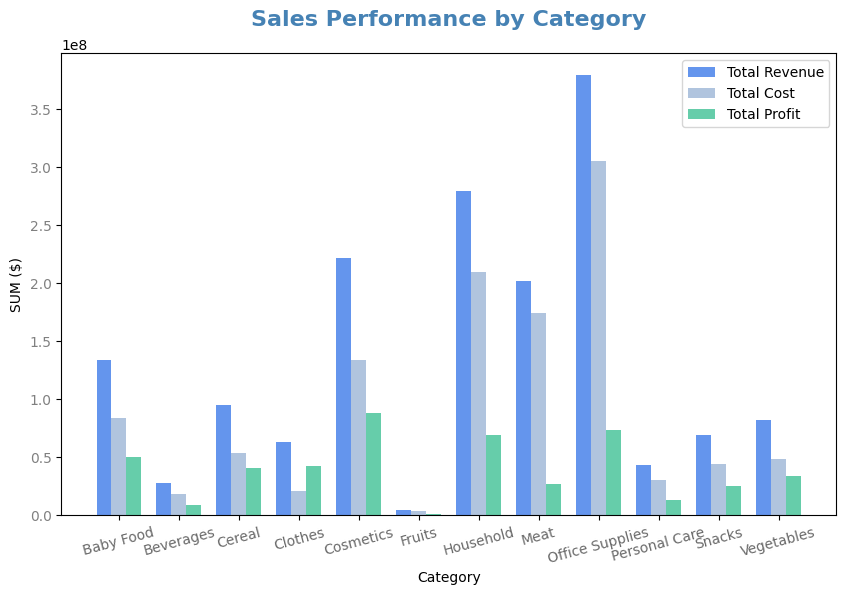

In [50]:
plt.figure(figsize=(10, 6))
x = np.arange(len(total_profit_by_category['product_category']))
width = 0.25

plt.bar(x - width, total_profit_by_category['total_revenue'], width, label='Total Revenue', color='cornflowerblue')
plt.bar(x, total_profit_by_category['total_cost'], width, label='Total Cost', color='lightsteelblue')
plt.bar(x + width, total_profit_by_category['total_profit'], width, label='Total Profit', color='mediumaquamarine')

plt.title("Sales Performance by Category",color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Category")
plt.ylabel("SUM ($)")
plt.xticks(x, total_profit_by_category['product_category'], rotation=15, fontsize=10, color='dimgrey')
plt.yticks(color='grey', fontsize=10)
plt.legend()
plt.show()

In [51]:
total_orders_by_category = df.groupby('product_category')['order_id'].count().reset_index().rename(columns={'order_id': 'count'}).sort_values(by='count', ascending=False)
total_orders_by_category

,product_category,count
1,Beverages,113
8,Office Supplies,113
4,Cosmetics,108
9,Personal Care,108
0,Baby Food,105
11,Vegetables,105
5,Fruits,103
3,Clothes,102
7,Meat,102
2,Cereal,101


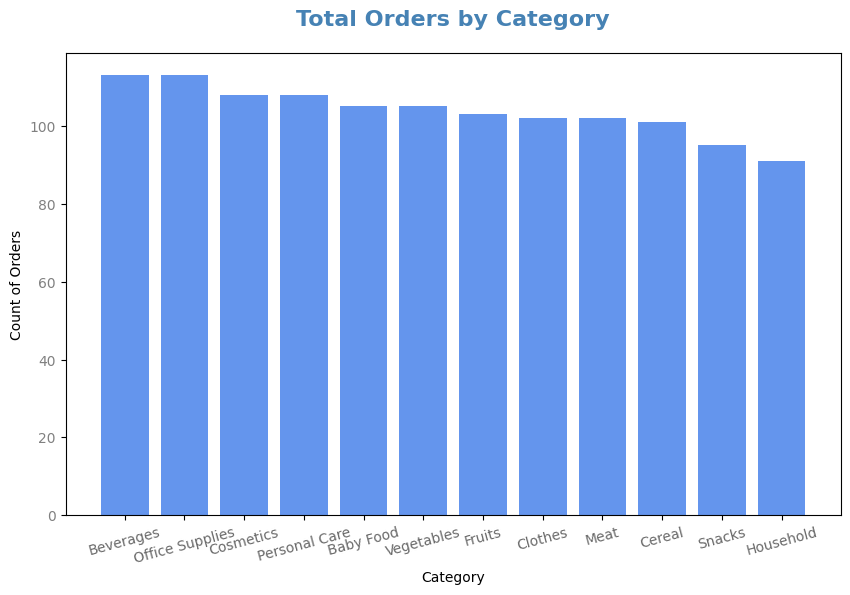

In [52]:
plt.figure(figsize=(10, 6))
x = np.arange(len(total_orders_by_category['product_category']))

plt.bar(x, total_orders_by_category['count'], color='cornflowerblue')

plt.title("Total Orders by Category",color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Category")
plt.ylabel("Count of Orders")
plt.xticks(x, total_orders_by_category['product_category'],rotation=15, fontsize=10, color='dimgrey')
plt.yticks(color='grey', fontsize=10)
plt.show()

***✅ географії (країн, регіонів);***

In [53]:
region_and_countries = df.groupby('region')['country_name'].nunique()
region_and_countries

,country_name
region,
Asia,3
Europe,42


In [54]:
total_orders_profit_by_countries = (df.groupby('country_name').agg(count=('order_id', 'count'),
                                                                   total_profit=('total_profit', 'sum')).reset_index()).sort_values(by='total_profit', ascending=False)
total_orders_profit_by_countries

,country_name,count,total_profit
1,Andorra,40,15410036.63
43,Ukraine,33,14804925.74
27,Malta,32,14610127.88
36,San Marino,40,13792992.81
18,Hungary,25,13786231.03
26,Macedonia,32,13684099.95
10,Czech Republic,31,13635593.78
35,Russia,32,13267682.64
6,Bosnia And Herzegovina,33,13257602.77
17,Greece,32,12324450.13


In [55]:
total_products_by_country = (df.groupby(['country_name', 'product_category']).agg(count=('order_id', 'count')).reset_index())
total_products_by_country

,country_name,product_category,count
0,Albania,Baby Food,1
1,Albania,Beverages,3
2,Albania,Clothes,3
3,Albania,Cosmetics,4
4,Albania,Household,3
...,...,...,...
483,United Kingdom,Household,2
484,United Kingdom,Office Supplies,1
485,United Kingdom,Personal Care,5
486,United Kingdom,Snacks,1


In [56]:
total_orders_profit_by_region = (df.groupby('region').agg(count=('order_id', 'count'), total_profit=('total_profit', 'sum')).reset_index())
total_orders_profit_by_region

,region,count,total_profit
0,Asia,82,25152252.95
1,Europe,1164,448556782.11


***✅ каналів продажу (онлайн або офлайн)***

In [57]:
orders_by_sales_channel = (df.groupby('sales_channel').agg(count=('order_id', 'count'), total_profit=('total_profit', 'sum')).reset_index())
orders_by_sales_channel

,sales_channel,count,total_profit
0,Offline,621,238511327.41
1,Online,625,235197707.65


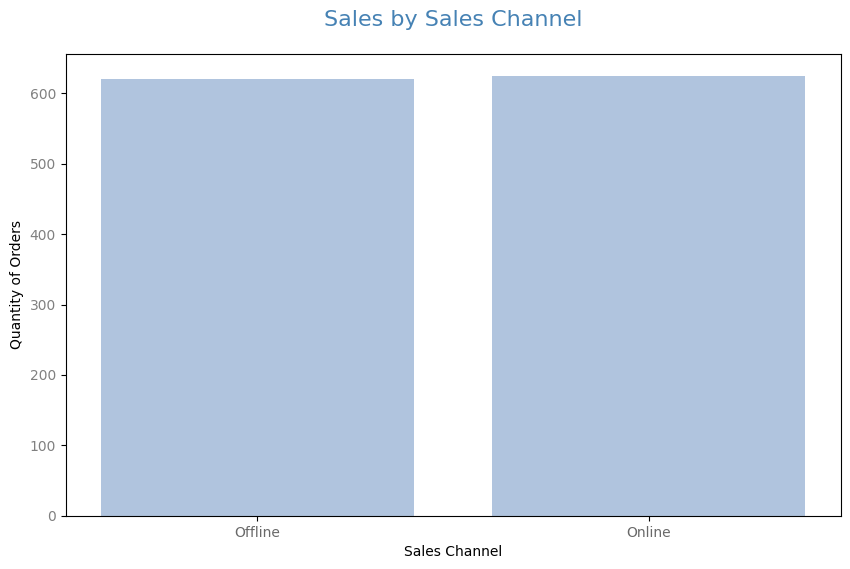

In [58]:
plt.figure(figsize=(10, 6))
x = np.arange(len(orders_by_sales_channel['sales_channel']))

plt.bar(x, orders_by_sales_channel['count'], color='lightsteelblue')

plt.title("Sales by Sales Channel",color='steelblue', fontsize=16, pad=20)
plt.xlabel("Sales Channel")
plt.ylabel("Quantity of Orders")
plt.xticks(x, orders_by_sales_channel['sales_channel'], fontsize=10, color='dimgrey')
plt.yticks(color='grey', fontsize=10)
plt.show()

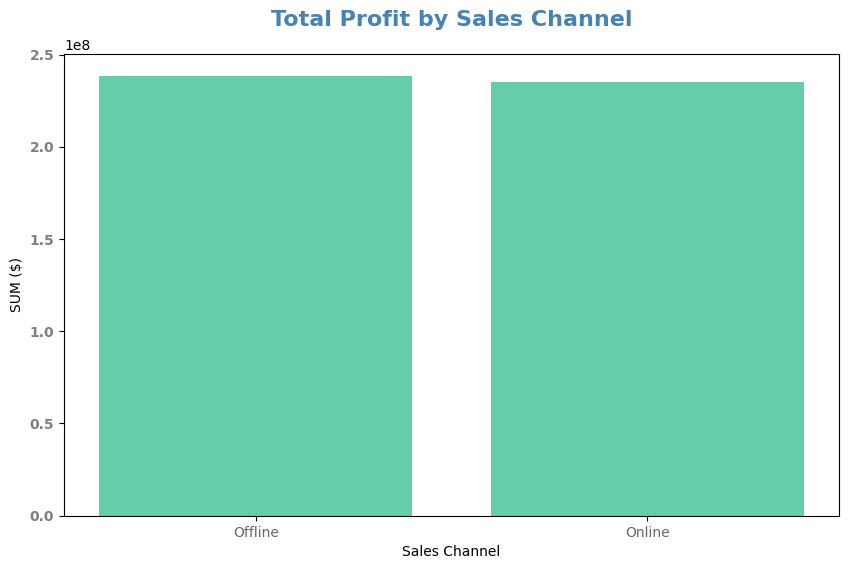

In [59]:
plt.figure(figsize=(10, 6))
x = np.arange(len(orders_by_sales_channel['sales_channel']))

plt.bar(x, orders_by_sales_channel['total_profit'], color='mediumaquamarine')

plt.title("Total Profit by Sales Channel",color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Sales Channel")
plt.ylabel("SUM ($)")
plt.xticks(x, orders_by_sales_channel['sales_channel'],fontsize=10, color='dimgrey')
plt.yticks(color='grey', fontsize=10,  fontweight='bold')
plt.show()

##

## 🔷***Проаналізуй інтервал часу між замовленням та його відвантаженням та зроби відповідні візуалізації в розрізі:***

* категорій товарів;

* країн;

* регіонів.

In [60]:
shipping_lead_time_by_category = df.groupby('product_category')['shipping_lead_time'].mean().round(0).astype(int).reset_index().sort_values(by='shipping_lead_time', ascending=False)
shipping_lead_time_by_category

,product_category,shipping_lead_time
0,Baby Food,27
2,Cereal,27
8,Office Supplies,27
4,Cosmetics,26
7,Meat,26
10,Snacks,25
3,Clothes,24
1,Beverages,24
6,Household,24
5,Fruits,24


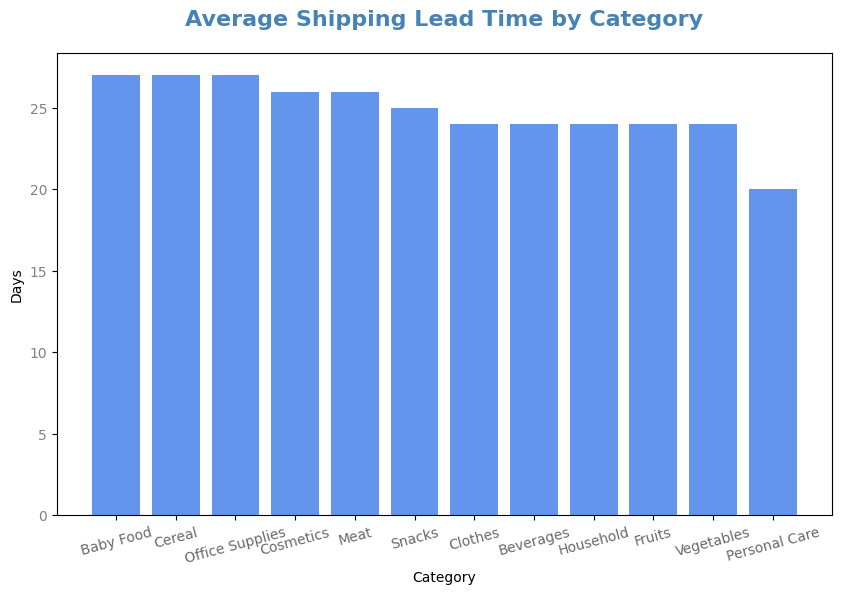

In [61]:
plt.figure(figsize=(10, 6))
x = np.arange(len(shipping_lead_time_by_category['product_category']))

plt.bar(x, shipping_lead_time_by_category['shipping_lead_time'], color='cornflowerblue')

plt.title("Average Shipping Lead Time by Category", color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Category")
plt.ylabel("Days")
plt.xticks(x, shipping_lead_time_by_category['product_category'],rotation=15, fontsize=10, color='dimgrey')
plt.yticks(color='grey', fontsize=10)
plt.show()

In [62]:
average_lead_time = df['shipping_lead_time'].mean().round(0)
average_lead_time

np.float64(25.0)

In [63]:
shipping_lead_time_by_countries = df.groupby('country_name')['shipping_lead_time'].mean().round(0).astype(int).reset_index().sort_values(by='shipping_lead_time', ascending=False)
shipping_lead_time_by_countries.head()

,country_name,shipping_lead_time
18,Hungary,33
15,Georgia,30
25,Luxembourg,28
24,Lithuania,28
3,Austria,28


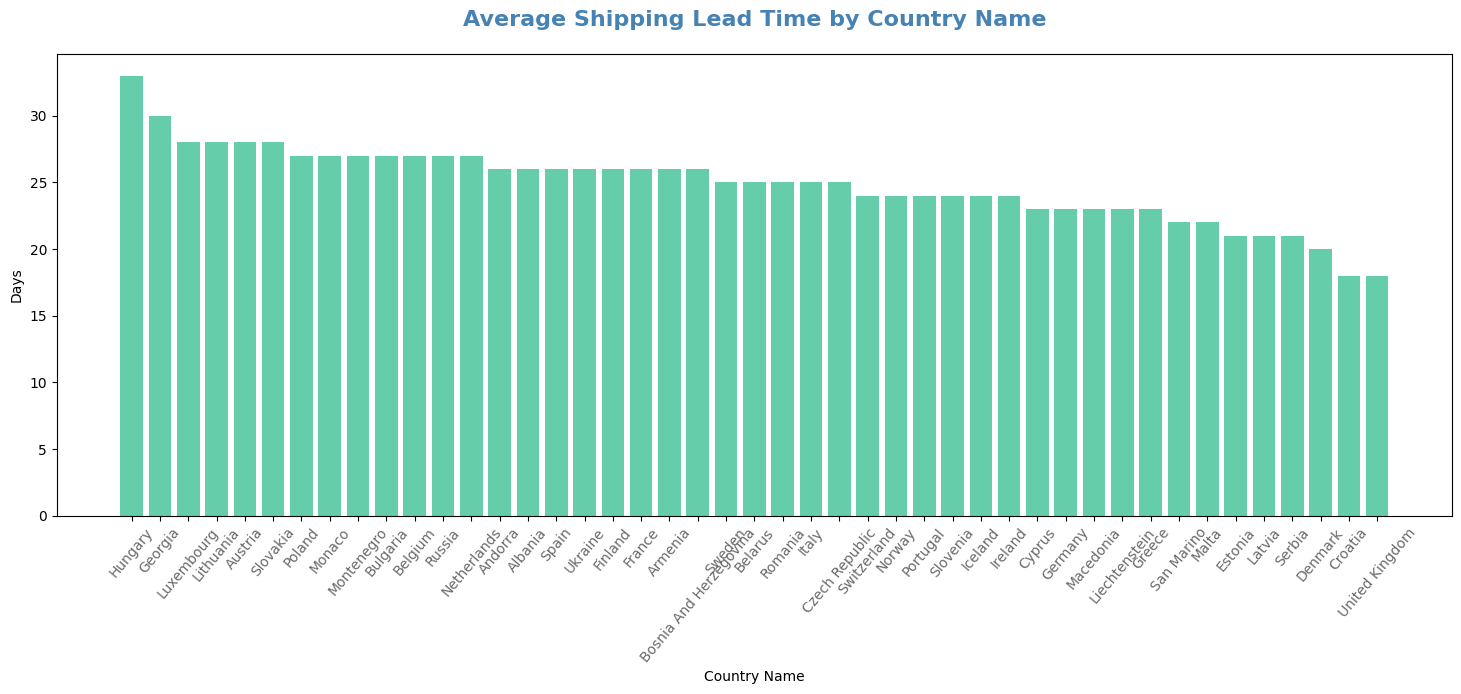

In [64]:
plt.figure(figsize=(18, 6))
x = np.arange(len(shipping_lead_time_by_countries['country_name']))

plt.bar(x, shipping_lead_time_by_countries['shipping_lead_time'], color='mediumaquamarine')

plt.title("Average Shipping Lead Time by Country Name", color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Country Name")
plt.ylabel("Days")
plt.xticks(x, shipping_lead_time_by_countries['country_name'],rotation=50, fontsize=10,  color='dimgrey')
plt.yticks(fontsize=10)

plt.show()

In [65]:
shipping_lead_time_by_region = df.groupby('region')['shipping_lead_time'].mean().round(0).astype(int).reset_index()
shipping_lead_time_by_region

,region,shipping_lead_time
0,Asia,26
1,Europe,25


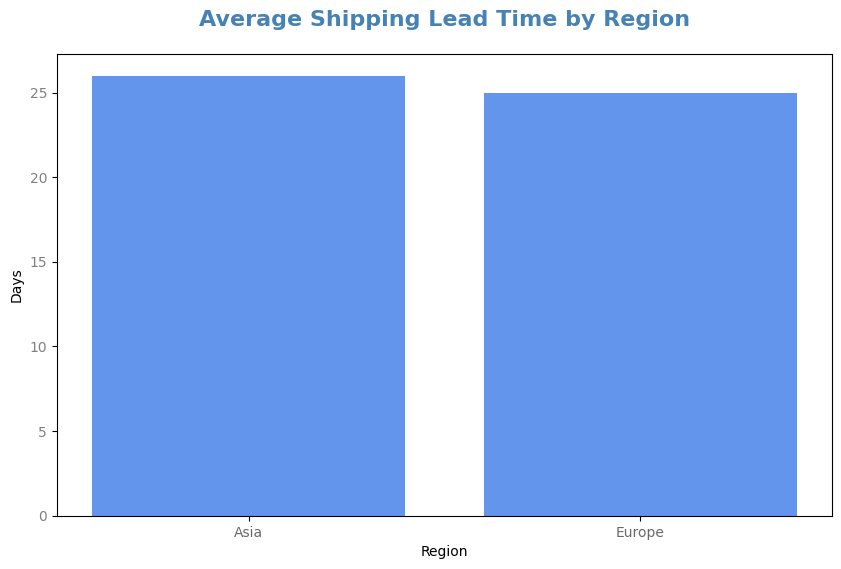

In [66]:
plt.figure(figsize=(10, 6))
x = np.arange(len(shipping_lead_time_by_region['region']))

plt.bar(x, shipping_lead_time_by_region['shipping_lead_time'], color='cornflowerblue')

plt.title("Average Shipping Lead Time by Region", color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Region")
plt.ylabel("Days")
plt.xticks(x, shipping_lead_time_by_region['region'], fontsize=10, color='dimgrey')
plt.yticks(color='grey', fontsize=10)
plt.show()

## 🔷***Проаналізуй, чи залежить прибуток від часу, необхідного на відвантаження товару. Зроби потрібні для цього агрегування та візуалізації.***

In [67]:
total_profit_shipping_lead_time = df.groupby('shipping_lead_time')['total_profit'].mean().reset_index().sort_values(by='shipping_lead_time', ascending=False)
total_profit_shipping_lead_time

,shipping_lead_time,total_profit
50,50,301503.96
49,49,433766.68
48,48,293461.05
47,47,564746.92
46,46,434119.88
45,45,351263.15
44,44,376415.26
43,43,384184.27
42,42,320388.37
41,41,436604.78


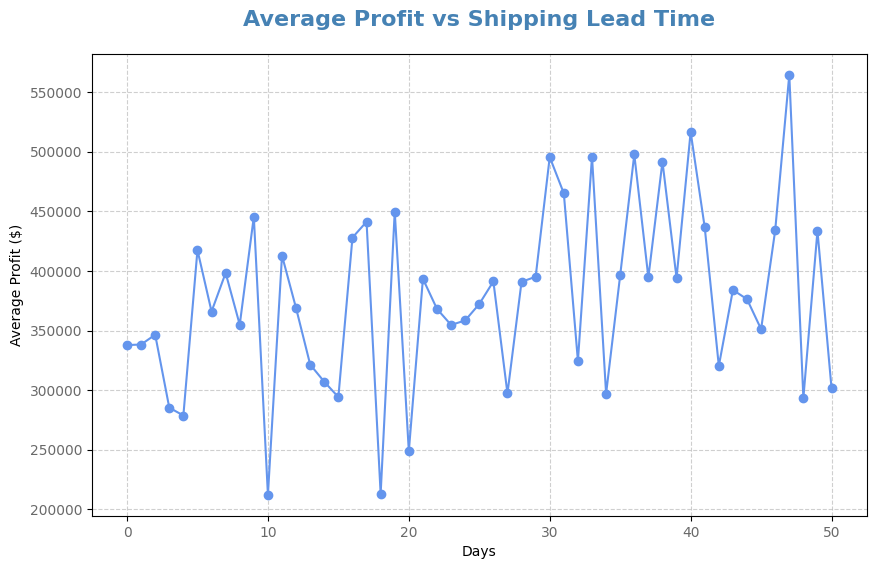

In [68]:
plt.figure(figsize=(10,6))
plt.plot(total_profit_shipping_lead_time['shipping_lead_time'], total_profit_shipping_lead_time['total_profit'], marker='o', color='cornflowerblue', label='Average Profit')

plt.title("Average Profit vs Shipping Lead Time",  color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Days")
plt.ylabel("Average Profit ($)")
plt.xticks(fontsize=10, color='dimgrey')
plt.yticks(color='dimgrey', fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

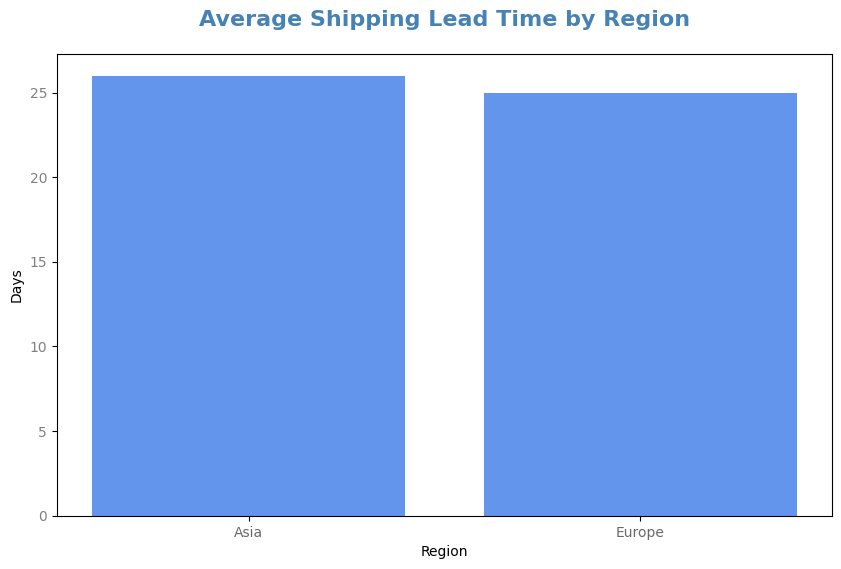

In [69]:
plt.figure(figsize=(10, 6))
x = np.arange(len(shipping_lead_time_by_region['region']))

plt.bar(x, shipping_lead_time_by_region['shipping_lead_time'], color='cornflowerblue')

plt.title("Average Shipping Lead Time by Region", color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Region")
plt.ylabel("Days")
plt.xticks(x, shipping_lead_time_by_region['region'], fontsize=10, color='dimgrey')
plt.yticks(color='grey', fontsize=10)
plt.show()

## 🔷 ***Проаналізуй за допомогою візуалізації динаміку продажів (у часі) у розрізі категорій товарів, країн, регіонів, визнач основні тенденції.***



In [70]:
sales_by_year = df.groupby(["year"]).agg(count_orders=("order_id", "count"), total_revenue=("total_revenue", "sum"),
                                         total_cost=("total_cost", "sum"), total_profit=("total_profit", "sum")).reset_index()
sales_by_year

,year,count_orders,total_revenue,total_cost,total_profit
0,2010,159,202254432.22,142436439.51,59817992.71
1,2011,163,214212346.59,149845335.65,64367010.94
2,2012,187,267560382.87,184490326.69,83070056.18
3,2013,150,175356128.28,124134198.60,51221929.68
4,2014,172,216974606.96,150995227.80,65979379.16
5,2015,150,213987012.19,155760502.65,58226509.54
6,2016,165,181278089.85,126178004.66,55100085.19
7,2017,100,127360762.30,91434690.64,35926071.66


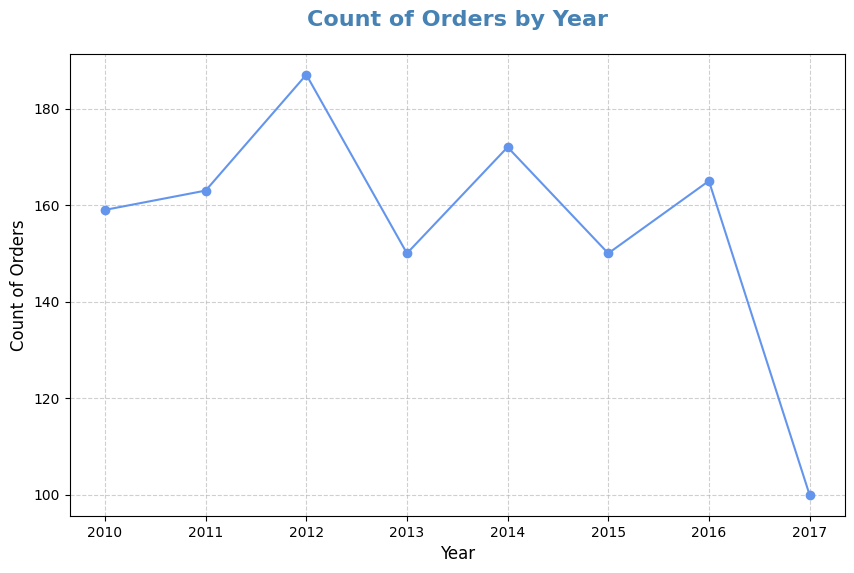

In [71]:
plt.figure(figsize=(10, 6))

plt.plot(sales_by_year['year'], sales_by_year['count_orders'], color='cornflowerblue', marker='o')
plt.title("Count of Orders by Year",  color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Count of Orders", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

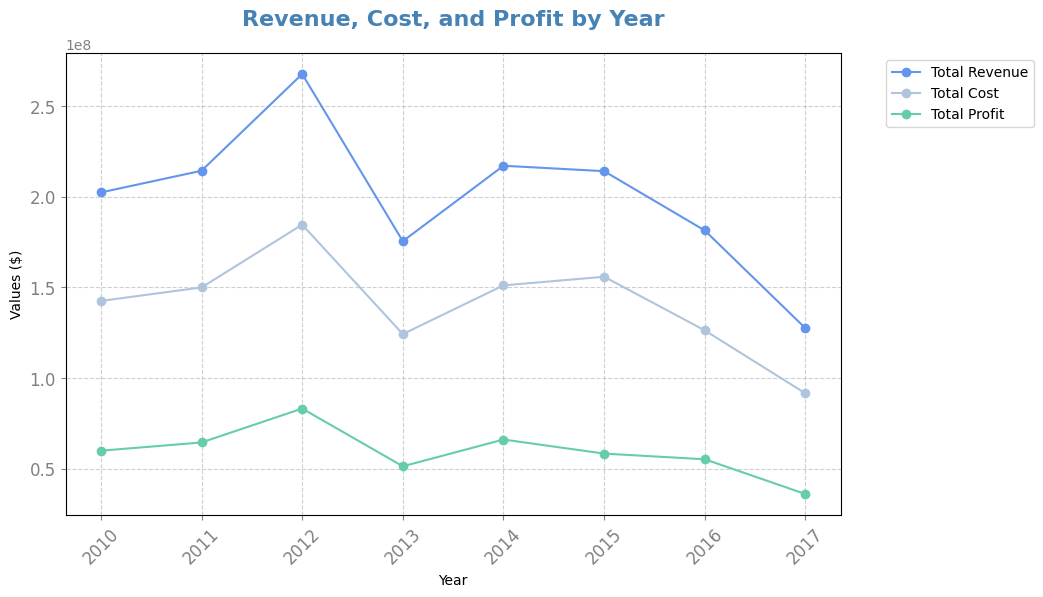

In [72]:
plt.figure(figsize=(10, 6))

plt.plot(sales_by_year['year'], sales_by_year['total_revenue'], label='Total Revenue', color='cornflowerblue', marker='o')
plt.plot(sales_by_year['year'], sales_by_year['total_cost'], label='Total Cost', color='lightsteelblue', marker='o')
plt.plot(sales_by_year['year'], sales_by_year['total_profit'], label='Total Profit', color='mediumaquamarine',  marker='o')

plt.title("Revenue, Cost, and Profit by Year",  color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Year", fontsize=10)
plt.ylabel("Values ($)", fontsize=10)
plt.tick_params(axis="x", rotation=45, colors="grey", labelsize=12)
plt.tick_params(axis="y", colors="grey", labelsize=12)

plt.legend( bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

***✅у розрізі категорій товарів, країн, регіонів, визнач основні тенденції.***

In [73]:
sales_by_year_category = df.groupby(['product_category', 'year']).agg(count_orders=("order_id", "count"),
                                                                      total_revenue=("total_revenue", "sum")).reset_index().sort_values(by='year', ascending=True)
sales_by_year_category

,product_category,year,count_orders,total_revenue
0,Baby Food,2010,15,18351313.36
8,Beverages,2010,14,3353101.70
24,Clothes,2010,12,7720304.16
16,Cereal,2010,17,17599280.60
48,Household,2010,13,33551831.89
...,...,...,...,...
47,Fruits,2017,6,384414.66
79,Personal Care,2017,6,2116071.43
71,Office Supplies,2017,9,34211317.35
87,Snacks,2017,13,11314417.32


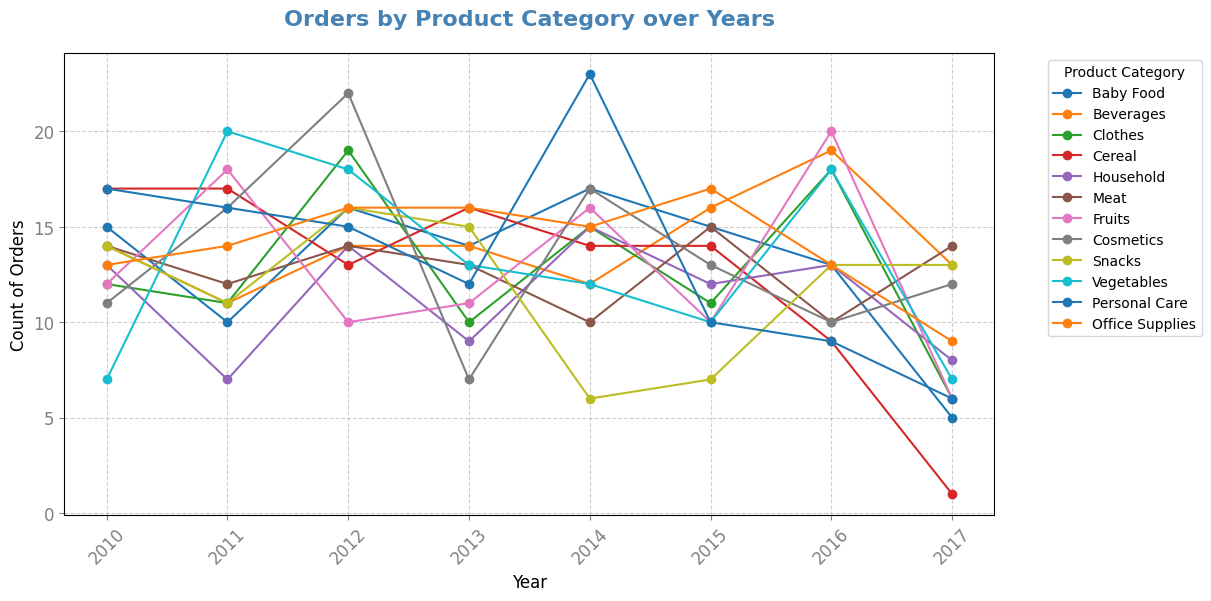

In [74]:
plt.figure(figsize=(12, 6))

for i in sales_by_year_category['product_category'].unique():
  subset = sales_by_year_category[sales_by_year_category['product_category'] == i]
  plt.plot(subset['year'], subset['count_orders'], marker='o', label=i)

plt.title("Orders by Product Category over Years", color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Count of Orders", fontsize=12)
plt.tick_params(axis="x", rotation=45, colors="grey", labelsize=12)
plt.tick_params(axis="y", colors="grey", labelsize=12)
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

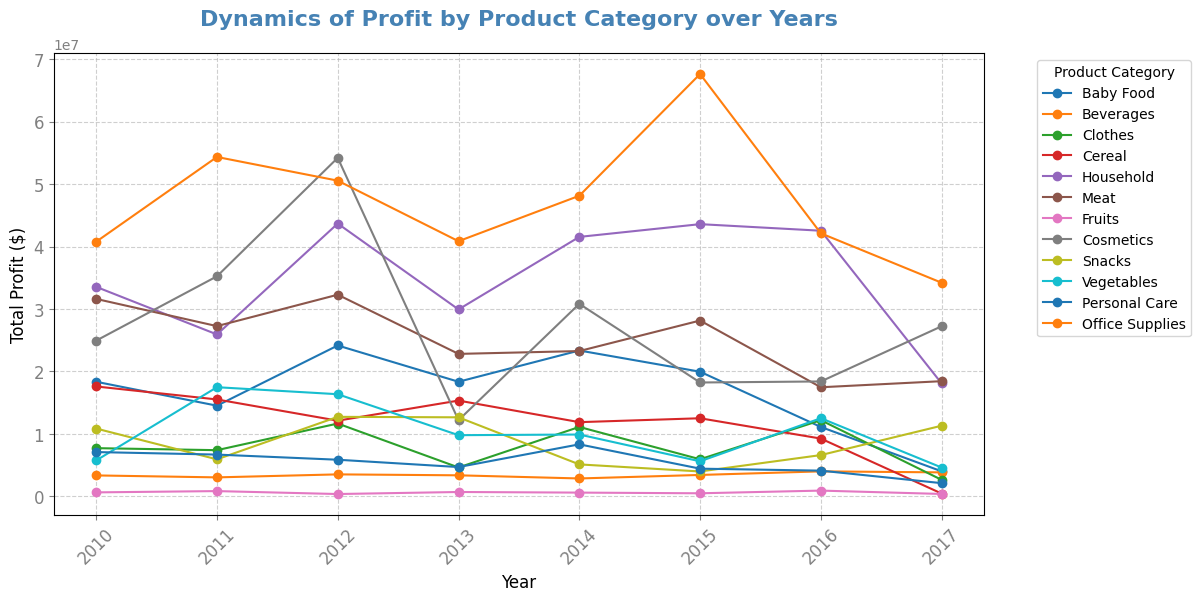

In [75]:
plt.figure(figsize=(12, 6))

for i in sales_by_year_category['product_category'].unique():
  subset = sales_by_year_category[sales_by_year_category['product_category'] == i]
  plt.plot(subset['year'], subset['total_revenue'], marker='o', label=i)

plt.title("Dynamics of Profit by Product Category over Years", color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total Profit ($)", fontsize=12)
plt.tick_params(axis="x", rotation=45, colors="grey", labelsize=12)
plt.tick_params(axis="y", colors="grey", labelsize=12)
plt.legend(title="Product Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

In [76]:
sales_by_year_countries = df.groupby(['year', 'country_name']).agg(count_orders=("order_id", "count"),
                                                                      total_revenue=("total_revenue", "sum")).reset_index()
sales_by_year_countries

,year,country_name,count_orders,total_revenue
0,2010,Albania,4,8531301.81
1,2010,Andorra,8,10463527.98
2,2010,Armenia,6,7672185.09
3,2010,Austria,5,11632719.09
4,2010,Belarus,5,2080164.18
...,...,...,...,...
345,2017,Spain,4,5252435.91
346,2017,Sweden,2,3829883.02
347,2017,Switzerland,2,4039973.25
348,2017,Ukraine,4,7347212.53


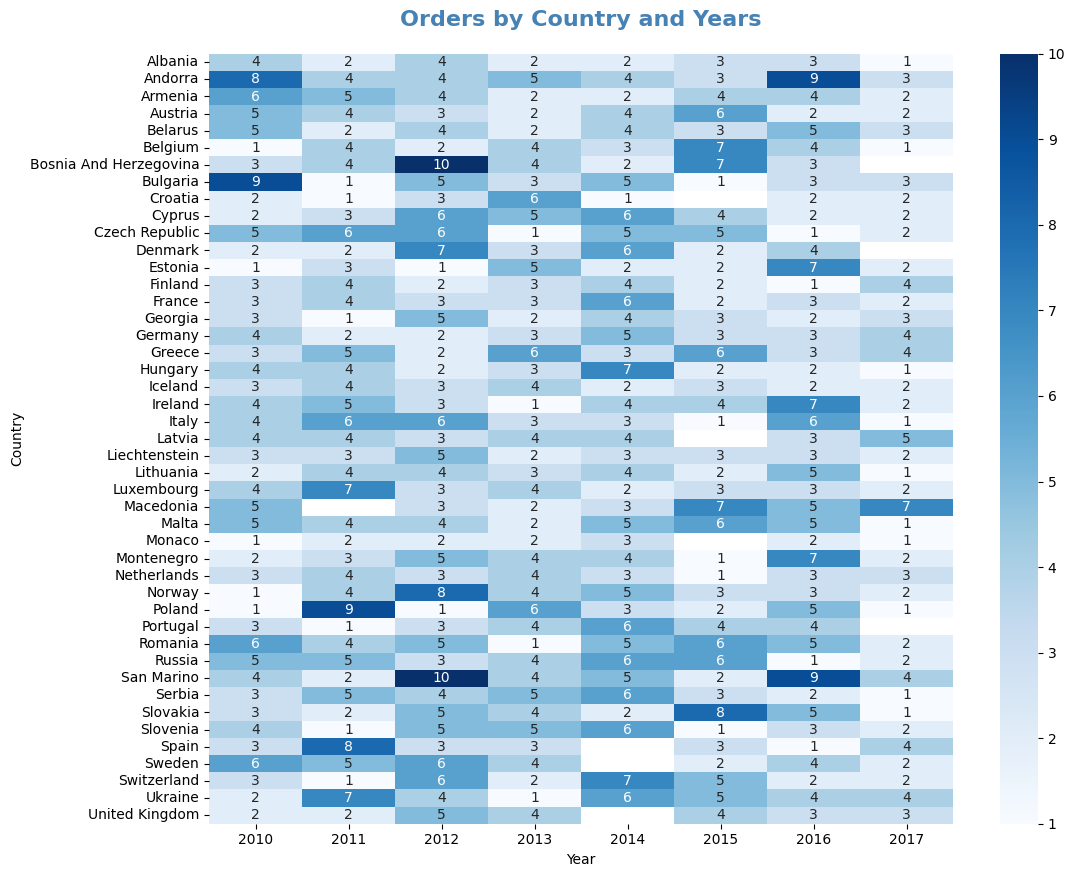

In [77]:
pivot_table = sales_by_year_countries.pivot(index='country_name', columns='year', values='count_orders')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, cmap="Blues", annot=True, fmt=".0f")
plt.title("Orders by Country and Years", fontsize=16, color='steelblue', fontweight='bold', pad=20)
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

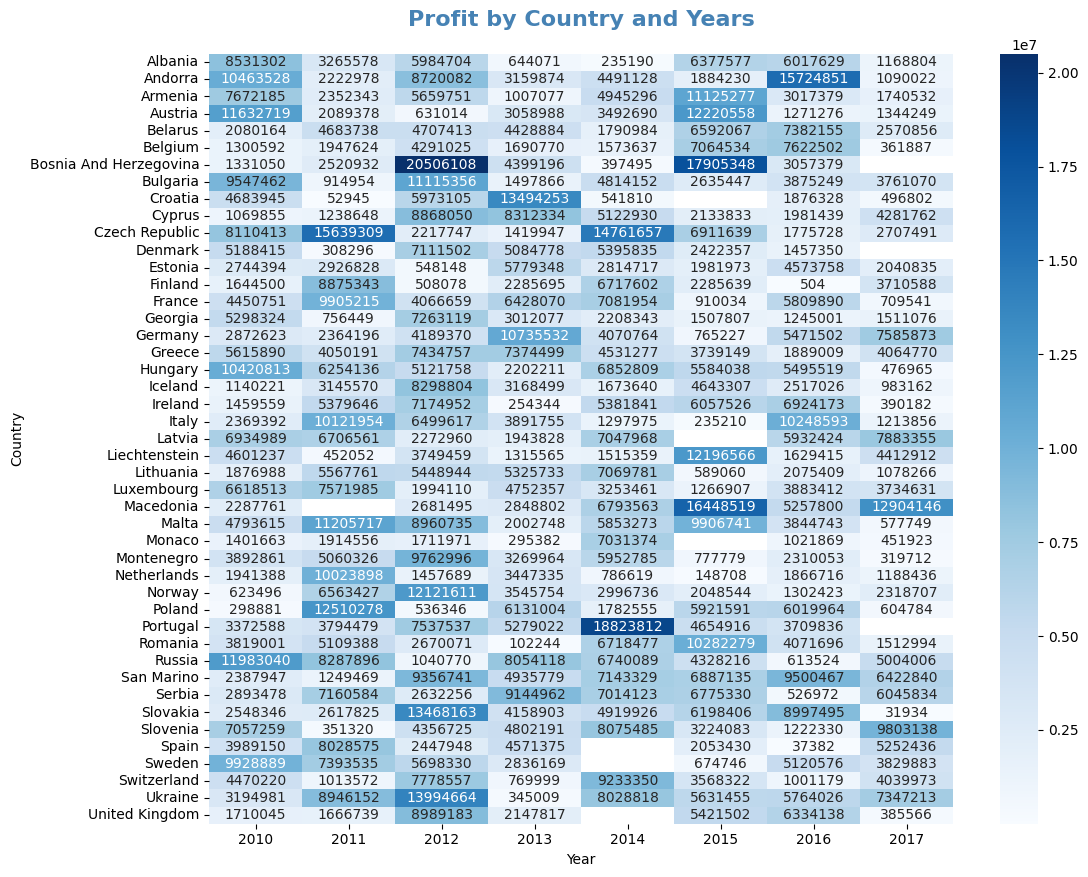

In [78]:
pivot_table = sales_by_year_countries.pivot(index='country_name', columns='year', values='total_revenue')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, cmap="Blues", annot=True, fmt=".0f")
plt.title("Profit by Country and Years", fontsize=16, color='steelblue', fontweight='bold', pad=20)
plt.xlabel("Year")
plt.ylabel("Country")
plt.show()

In [79]:
sales_by_year_region = df.groupby(['year', 'region']).agg(count_orders=("order_id", "count"),
                                                                      total_revenue=("total_revenue", "sum")).reset_index()
sales_by_year_region

,year,region,count_orders,total_revenue
0,2010,Asia,11,14040364.13
1,2010,Europe,148,188214068.09
2,2011,Asia,9,4347439.86
3,2011,Europe,154,209864906.73
4,2012,Asia,15,21790920.12
5,2012,Europe,172,245769462.75
6,2013,Asia,9,12331488.07
7,2013,Europe,141,163024640.21
8,2014,Asia,12,12276568.25
9,2014,Europe,160,204698038.71


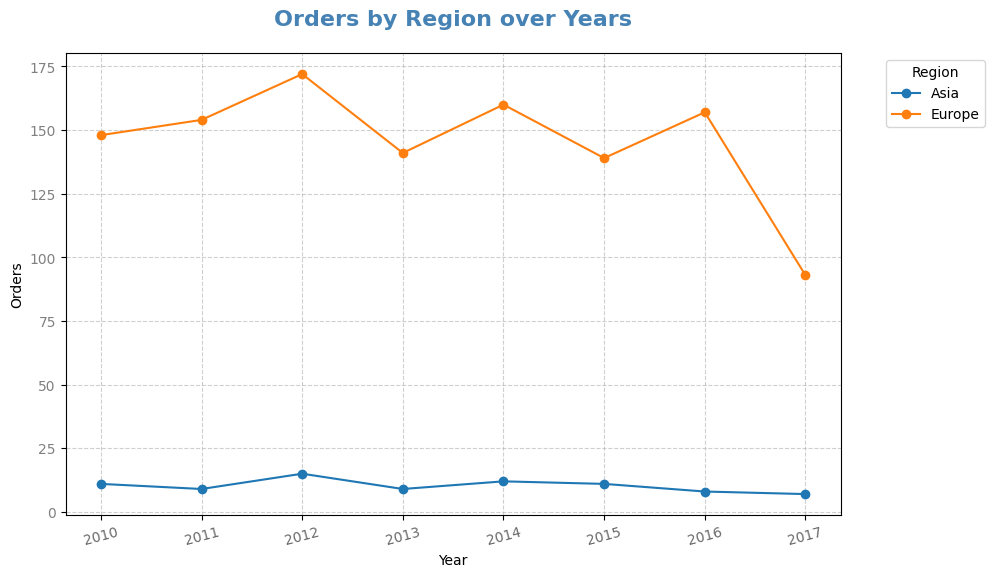

In [80]:
plt.figure(figsize=(10, 6))

for region in sales_by_year_region['region'].unique():
    subset = sales_by_year_region[sales_by_year_region['region'] == region]
    plt.plot(subset['year'], subset['count_orders'], marker='o', label=region)

plt.title("Orders by Region over Years", color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Year")
plt.ylabel("Orders")
plt.xticks(rotation=15, fontsize=10, color='dimgrey')
plt.yticks(color='grey', fontsize=10)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

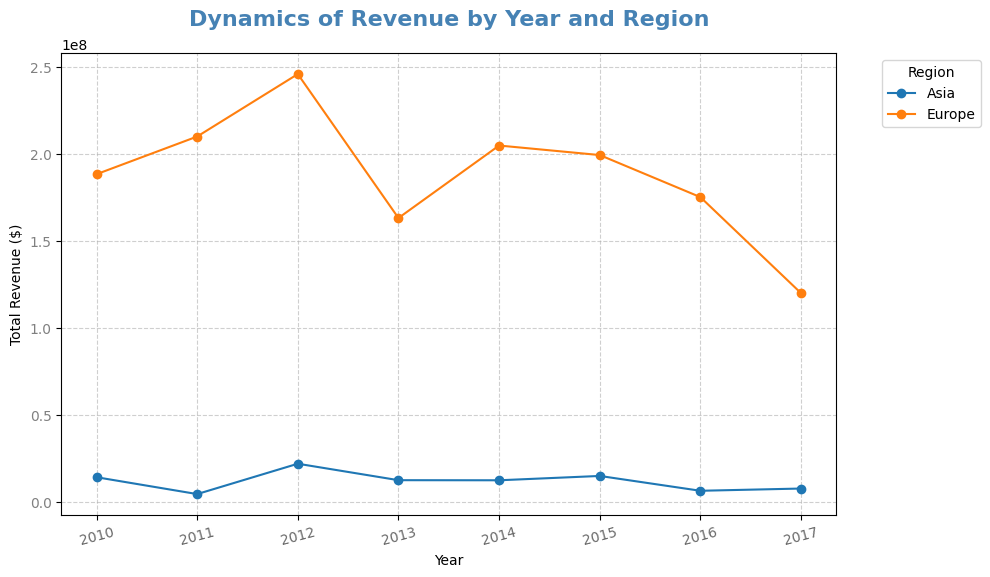

In [81]:
plt.figure(figsize=(10, 6))

for region in sales_by_year_region['region'].unique():
    subset = sales_by_year_region[sales_by_year_region['region'] == region]
    plt.plot(subset['year'], subset['total_revenue'], marker='o', label=region)

plt.title("Dynamics of Revenue by Year and Region", color='steelblue', fontweight='bold', fontsize=16, pad=20)
plt.xlabel("Year")
plt.ylabel("Total Revenue ($)")
plt.xticks(rotation=15, fontsize=10, color='dimgrey')
plt.yticks(color='grey', fontsize=10)
plt.legend(title="Region", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle="--", alpha=0.6)

plt.show()

✅***Проаналізуй динаміку продажів за роками та місяцями у розрізі:***

  * категорій товарів;

  * країн;

  * регіонів;

***Визнач основні тенденції.***

***Стабільні категорії:*** Meat, Office Supplies, Beverages

***Найбільший прибуток*** –  Cosmetics, Office Supplies, Household

***Найменьший прибуток*** – Fruits, Personal Care, Cereal

***По регіонам:*** Європа домінує за обсягами продукцією та прибутками, ніж Азія
2017 рік – спад показників кількості замовлень і відповідно прибутковості

## 🔷 ***Проведи аналіз продажів товарів за днями тижня. Чи можна деякі товари вважати сезонними?***



In [82]:
sales_by_weekday = df.groupby(["weekday", "product_category"]).agg(count_orders=("order_id", "count"), total_revenue=("total_revenue", "sum"),
                                         total_cost=("total_cost", "sum"), total_profit=("total_profit", "sum")).reset_index()
sales_by_weekday

,weekday,product_category,count_orders,total_revenue,total_cost,total_profit
0,Friday,Baby Food,15,19808451.60,12370194.90,7438256.70
1,Friday,Beverages,9,2363674.30,1583587.06,780087.24
2,Friday,Cereal,12,12884430.90,7335419.07,5549011.83
3,Friday,Clothes,9,5814788.80,1907046.40,3907742.40
4,Friday,Cosmetics,27,57774668.40,34798269.51,22976398.89
...,...,...,...,...,...,...
79,Wednesday,Meat,15,33687916.50,29120496.50,4567420.00
80,Wednesday,Office Supplies,20,59169591.81,47698390.56,11471201.25
81,Wednesday,Personal Care,13,5266517.74,3651701.46,1614816.28
82,Wednesday,Snacks,10,5546588.16,3542138.88,2004449.28


In [83]:
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
sales_by_weekday["weekday"] = pd.Categorical(sales_by_weekday["weekday"], categories=weekday_order, ordered=True)
sales_by_weekday = sales_by_weekday.sort_values("weekday")
sales_by_weekday

,weekday,product_category,count_orders,total_revenue,total_cost,total_profit
23,Monday,Vegetables,19,14660965.84,8653262.52,6007703.32
22,Monday,Snacks,20,15663252.48,10002800.64,5660451.84
21,Monday,Personal Care,10,4252575.36,2948653.44,1303921.92
20,Monday,Office Supplies,14,57777956.04,46576551.04,11201405.00
19,Monday,Meat,17,35794413.27,30941393.67,4853019.60
...,...,...,...,...,...,...
43,Sunday,Meat,13,21602877.45,18673951.45,2928926.00
44,Sunday,Office Supplies,19,60057842.25,48414436.00,11643406.25
45,Sunday,Personal Care,20,6852243.20,4751212.80,2101030.40
47,Sunday,Vegetables,19,15724750.14,9281134.17,6443615.97


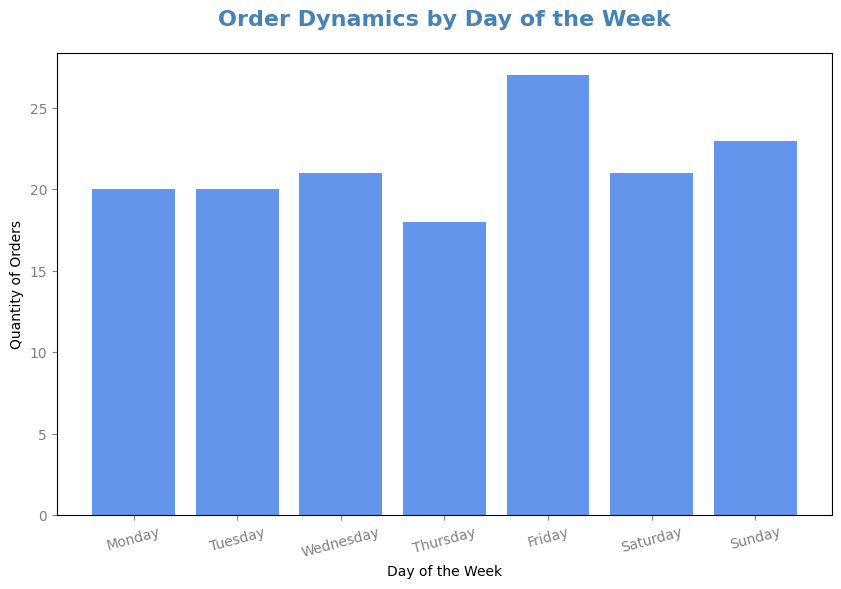

In [84]:
plt.figure(figsize=(10, 6))

plt.bar(sales_by_weekday['weekday'], sales_by_weekday['count_orders'], color='cornflowerblue')
plt.title("Order Dynamics by Day of the Week", fontsize=16, color='steelblue', fontweight='bold', pad=20)
plt.xlabel("Day of the Week")
plt.ylabel("Quantity of Orders")
plt.tick_params(axis="x", rotation=15, colors="grey", labelsize=10)
plt.tick_params(axis="y", colors="grey", labelsize=10)

plt.show()

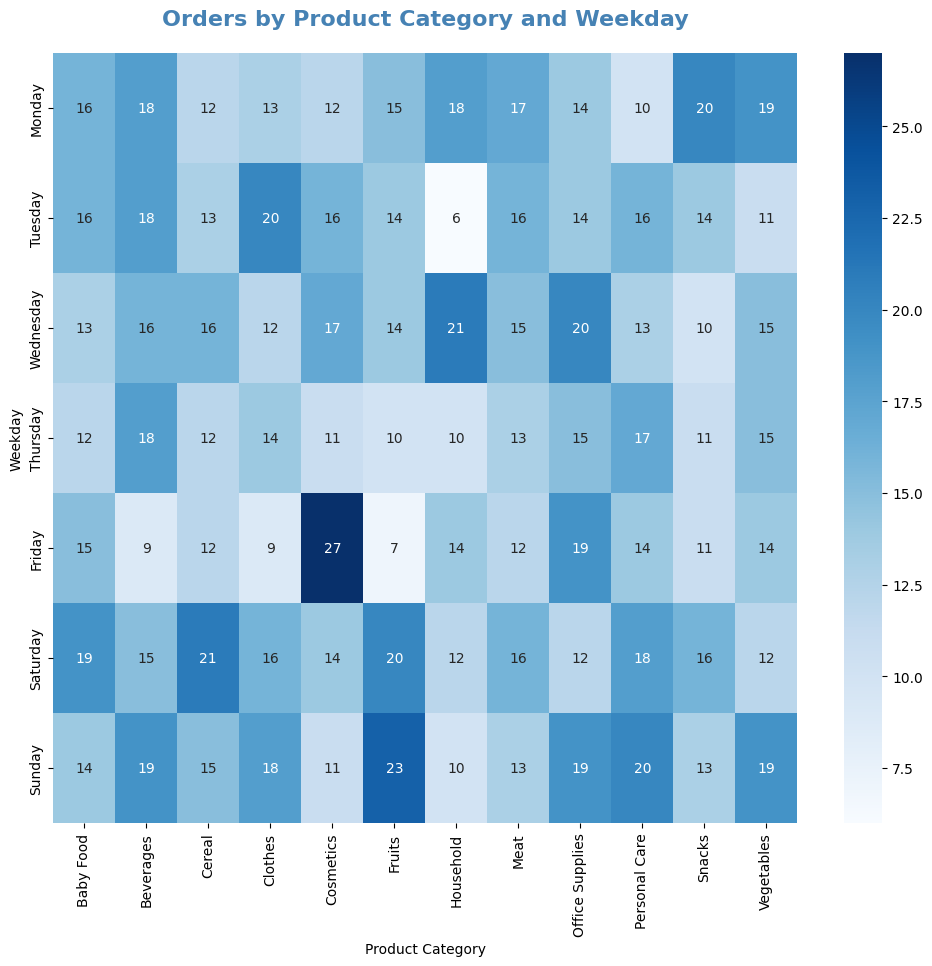

In [85]:
pivot_table = sales_by_weekday.pivot(index='weekday', columns='product_category', values='count_orders')

plt.figure(figsize=(12, 10))
sns.heatmap(pivot_table, cmap="Blues", annot=True, fmt=".0f")
plt.title("Orders by Product Category and Weekday",  fontsize=16, color='steelblue', fontweight='bold', pad=20)
plt.xlabel("Product Category")
plt.ylabel("Weekday")

plt.show()

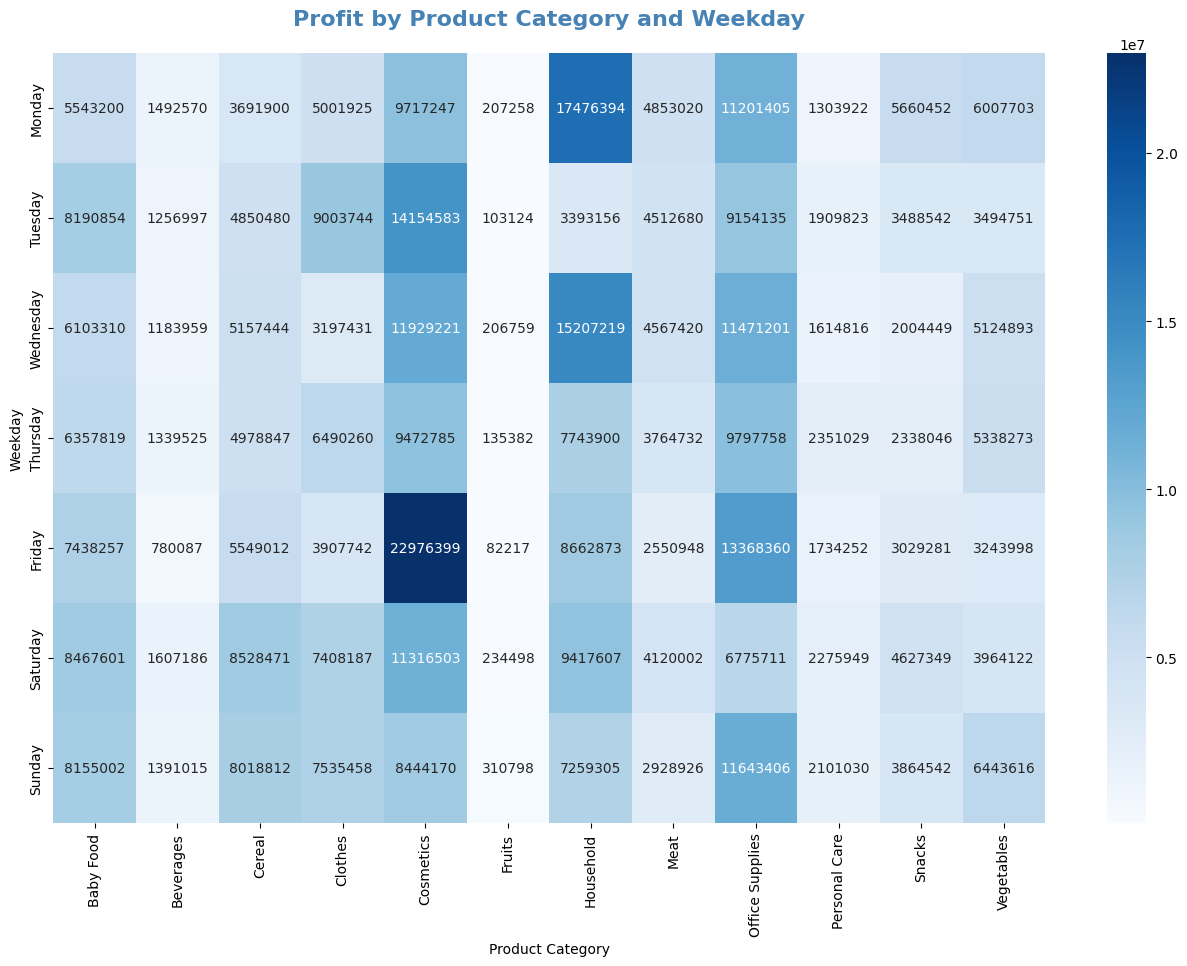

In [86]:
pivot_table = sales_by_weekday.pivot(index='weekday', columns='product_category', values='total_profit')

plt.figure(figsize=(16, 10))
sns.heatmap(pivot_table, cmap="Blues", annot=True, fmt=".0f")
plt.title("Profit by Product Category and Weekday", fontsize=16, color='steelblue', fontweight='bold', pad=20)
plt.xlabel("Product Category")
plt.ylabel("Weekday")

plt.show()

✅

  * П'ятниця, субота та неділя - зростання продажів в ці дні.

  * З понеділка по четвер - продажі слабкі

# ✅   ***Reporting***

***✅ Бізнес-висновок:***

* ✅ загальна кількість замовлень: 1 246;

* ✅ загальний прибуток: ~ 474 млн;

* ✅ загальна кількість охоплених країн: 45;

***Ядро бізнесу:*** `Cosmetics, Office Supplies, Meat` — стратегічні товари, що формують основний прибуток.

`Household` — нішевий, але високоприбутковий сегмент.

`Snacks` — перспективний товар для просування.

`Clothes, Beverages, Fruits, Personal Care, Cereal` – товари з низьким впливом на фінансовий результат компанії.


***Географія***: Європа — ключовий регіон (42 країни), Азія має потенціал, але охоплено лише 3 країни.

***Канали***: Online та Offline майже однакові — можна розвивати обидва.

***Логістика***: середній час доставки — 25 днів, але в окремих країнах (Угорщина, Грузія) він занадто високий -> ризик втрати клієнтів.